# CLIP Utilities Test

This notebook tests the functionality of `src/clip_utils.py` on Google Colab. It authenticates with Hugging Face, loads the CLIP model, and generates text embeddings for the S3DIS classes.

### 1. Setup & Mount Drive

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_DIR = '/content/Deep_learning_project'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Gandata/Deep_learning_project.git {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull origin dev

%cd {REPO_DIR}

# Install uv and dependencies
!pip install uv
!uv pip install --system -e .

Mounted at /content/drive
Cloning into '/content/Deep_learning_project'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 94 (delta 40), reused 64 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 30.57 MiB | 40.60 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/Deep_learning_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 71.6 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 97 packages in 841ms
Prepared 13 packages in 16.79s
Uninstalled 2 packages in 12ms
Installed 13 packages in 139ms
 + addict==2.4.0
 + comm==0.2.3
 + configargparse==1.7.5
 + dash==4.1.0
 + deep-learning-project==0.1.0 (from file:///content/Deep_learning_project)
 + ftfy==6.3.1
 - ipywidgets==7.7.1
 + ipywidgets==8.1.8
 + jedi==0.19.2
 + open-clip-torch==3.3.0
 + open3d==0.19.0
 + pyquaternion==0.9.9
 + retrying==1.4.2
 - widgetsnbextension==3.6.10
 +

We map the Drive folders directly into the repository so our scripts can find them.

In [2]:
# Symlink Drive data
!rm -f data checkpoints features pretrained
!ln -sf /content/drive/MyDrive/DL_Project/data ./data
!ln -sf /content/drive/MyDrive/DL_Project/checkpoints ./checkpoints
!ln -sf /content/drive/MyDrive/DL_Project/features ./features

### 2. Setup Hugging Face Token
Input your Hugging Face token below to allow authenticated downloads if necessary.

In [3]:
# If token is in colab secrets

from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

# Write to .env
with open(".env", "w") as f:
    f.write(f"HF_TOKEN={HF_TOKEN}\n")

In [ ]:
# If it is not on colab secrets, paste it
import getpass
import os

print("Enter your Hugging Face token (it will not be saved in the notebook):")
hf_token = getpass.getpass()

# Write to .env
with open(".env", "w") as f:
    f.write(f"HF_TOKEN={hf_token}\n")

### 3. Run CLIP Utilities
This will load the CLIP model and generate embeddings for the S3DIS categories defined in `src/dataset.py`.

In [5]:
!python src/clip_utils.py

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Loading CLIP model on cpu...
open_clip_model.safetensors: 100% 605M/605M [00:09<00:00, 62.7MB/s]
Computing CLIP embeddings for S3DIS classes...
/content/Deep_learning_project/src/clip_utils.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Saved CLIP embeddings to data/s3dis_processed/label_to_clip_embeddings.npy (shape: (13, 512))


### 4. Verify Results
Check if the embeddings file was correctly generated in the data directory.

In [6]:
import numpy as np
from pathlib import Path

emb_path = Path('data/s3dis_processed/label_to_clip_embeddings.npy')
if emb_path.exists():
    embeddings = np.load(emb_path)
    print(f"✅ Success! Embeddings saved to {emb_path}")
    print(f"Shape: {embeddings.shape} (should be 13, 512)")
else:
    print(f"❌ Error: Embeddings file not found at {emb_path}")

✅ Success! Embeddings saved to data/s3dis_processed/label_to_clip_embeddings.npy
Shape: (13, 512) (should be 13, 512)


### 5. Analysis: Similarity Matrix
Let's see how similar the class embeddings are to each other. High similarity between different classes (e.g., 'table' vs 'desk') is expected, but 'ceiling' should be distinct from 'chair'.

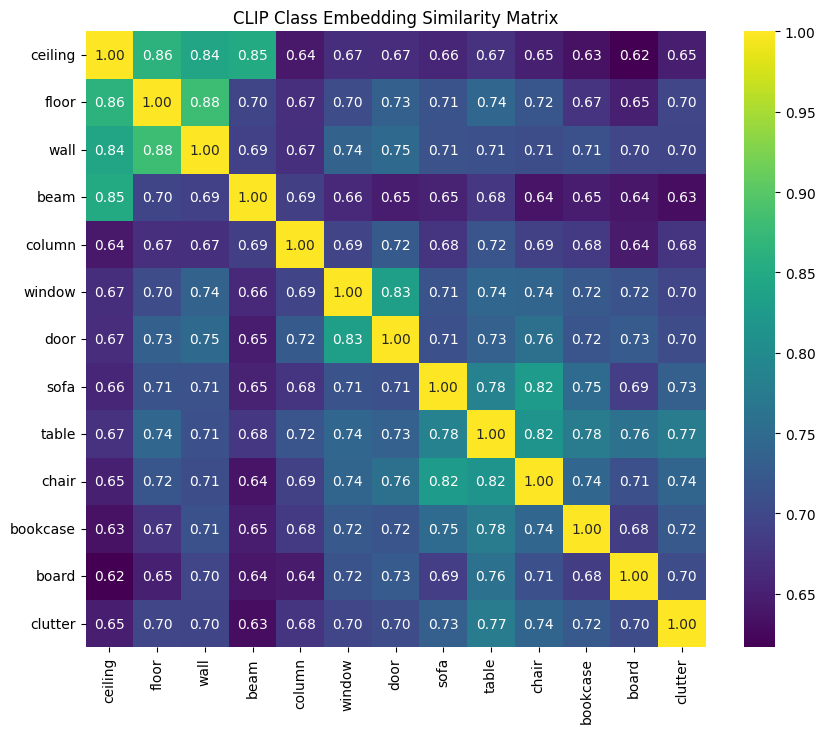

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.dataset import LABEL_MAP

# Compute cosine similarity matrix (dot product of L2 normalized embeddings)
similarity_matrix = embeddings @ embeddings.T

labels = [LABEL_MAP[i] for i in range(len(LABEL_MAP))]

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels, cmap='viridis')
plt.title("CLIP Class Embedding Similarity Matrix")
plt.show()

### 6. Interactive Query Testing
Test how a custom text query matches against our 13 classes.

In [11]:
import torch
import open_clip
from src.clip_utils import get_text_embedding

# Reuse the model already loaded in step 3 if running in same session,
# otherwise load it here:
try:
    model
except NameError:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    model.eval()

query = input("Enter a test query (e.g. 'office chair'): ")
query_emb = get_text_embedding(model, tokenizer, query, device=device).cpu().numpy()

# Compute similarities
similarities = embeddings @ query_emb

print(f"\nQuery: '{query}'")
results = sorted(zip(labels, similarities), key=lambda x: x[1], reverse=True)
for label, score in results:
    print(f"  {label:12s}: {score:.4f}")

Enter a test query (e.g. 'office chair'): pen

Query: 'pen'
  table       : 0.6729
  door        : 0.6399
  clutter     : 0.6318
  board       : 0.6311
  chair       : 0.6292
  window      : 0.6091
  sofa        : 0.5918
  column      : 0.5880
  bookcase    : 0.5799
  wall        : 0.5510
  floor       : 0.5396
  beam        : 0.5393
  ceiling     : 0.5093
